In [1]:
import pandas as pd
import yfinance as yf
import requests
import datetime as dt
import time

In [2]:
import pyodbc
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import urllib

In [ ]:

#  Em Call dữ liệu về (Chỗ nãy không cần hiểu đâu)
class CollectData:
    def __init__(self):
        self.data=pd.DataFrame()
    def get_corn_price(self):
        print('Lấy giá ngô:')
        try:
            corn= yf.download("ZC=F", start='2020-01-01', progress='False')
            self.data['corn_price']=corn['Close'] #lấy giá close của ngô
            print(f'Đã lấy {len(corn)} records giá ngô')
        except Exception as e:
            print(f'Lỗi lấy giá ngô:{e}')
    def get_related_prices(self):
        print('Lấy giá các mặt hàng liên quan')
        try:
            #lấy giá dầu
            oil = yf.download("CL=F", start='2020-01-01', progress='False')
            self.data['Oil_Price']=oil['Close']
            #lấy giá lúa mì
            wheat=yf.download("ZW=F", start='2020-01-01', progress='False')
            self.data['Wheat_Price']=wheat['Close']
            #lấy giá đậu nành
            soybean=yf.download("ZS=F", start='2020-01-01', progress='False')
            self.data['SoyBean']=soybean['Close']
            #lấy tỉ giá usd_index
            usd_index = yf.download("DX=F", start="2020-01-01", progress='False')
            self.data['usd_index'] = usd_index['Close']
        except Exception as e:
            print(f'Lỗi lấy giá dầu:{e}')
    def create_features(self):
        print('Fill dữ liệu trống')
        print('Thêm các cột giá trị mới:')
        self.data['price_lag_1'] = self.data['corn_price'].shift(1)  # Giá ngày hôm trước
        self.data['price_lag_7'] = self.data['corn_price'].shift(7)  # Giá 7 ngày trước
        self.data['moving_avg_7'] = self.data['corn_price'].rolling(7).mean() #giá trung bình 7 ngày gần nhất
        self.data['moving_avg_30'] = self.data['corn_price'].rolling(30).mean()#giá trung bình 30 ngày gần nhất
        self.data.dropna(inplace=True)
    def save_to_csv(self,filename ='corn_data.csv'):
        try:
            self.data.to_csv(filename)
            print('Đã lưu file')
        except Exception as e:
            print('Lỗi')
    def Collect_all_data(self):
        self.get_corn_price()
        time.sleep(2)  
        
        self.get_related_prices()
        time.sleep(2)
        
        self.create_features()
        
        # Lưu dữ liệu
        self.save_to_csv()
        return self.data
    
     


    


In [ ]:
    #def save_to_sql(self,table_name="Corn_Prices"):
        #try:
            #print('Đang import dữ liệu vào SQL...')
            #load_dotenv("coffee_db.env")
            #CONN = os.getenv('SQL_CONN')
            #print(CONN)
            #engine = create_engine(f"mssql+pyodbc://LAPTOP-OPQ5F34C\\SQLEXPRESS/Uyen123?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes")
            #self.data.to_sql(table_name, con=engine, if_exists='replace', index=True)
            #print('✅ Đã import thành công')
        #except Exception as e:
            #print(f'Lỗi khi import SQL: {e}')
#  self.save_to_sql()

In [ ]:
#Gắn dữ liệu
collector = CollectData()
data = collector.Collect_all_data()

Lấy giá ngô:


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20840\2316484580.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  corn= yf.download("ZC=F", start='2020-01-01', progress='False')
[*********************100%***********************]  1 of 1 completed


Đã lấy 1549 records giá ngô
Lấy giá các mặt hàng liên quan


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20840\2316484580.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  oil = yf.download("CL=F", start='2020-01-01', progress='False')
[*********************100%***********************]  1 of 1 completed
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20840\2316484580.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  wheat=yf.download("ZW=F", start='2020-01-01', progress='False')
[*********************100%***********************]  1 of 1 completed
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20840\2316484580.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  soybean=yf.download("ZS=F", start='2020-01-01', progress='False')
[*********************100%***********************]  1 of 1 completed
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20840\2316484580.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_index =

Fill dữ liệu trống
Thêm các cột giá trị mới:
Đã lưu file
Đang import dữ liệu vào SQL...
mssql+pyodbc://LAPTOP-OPQ5F34C\SQLEXPRESS/AdventureWorks?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes
✅ Đã import thành công


In [ ]:
#class getdatango():
    #def __init__(self):
        #self.data = pd.DataFrame()  
        #self.item_code = "56"
        #self.Start_year=2021
        #self.End_year=2022
    #def laydatango(self):
        #all_data=[]
        #for year in range(self.Start_year, self.End_year + 1):
            #try:
                #url =f"https://fenixservices.fao.org/faostat/api/v1/en/data/QC?item_code=56&area_code=5000&year={year}&show_codes=true&show_unit=true"
                #print(f"Đang lấy dữ kiệu năm {year}..")
                #response= requests.get(url)
                #if response.status_code == 200:
                    #data_json = response.json()
                    #if "data" in data_json and data_json["data"]:#kiểm tra có khóa "data" trong phản hồi không và ds data có rỗng không
                        #df =pd.DataFrame(data_json["data"])
                        #df["year"] =year
                        #all_data.append(df)
                        #print(f"Đã lây được dữ liệu năm {year}")
                    #else:
                        #print(f"Không lấy được dữ liệu năm {year}")
                #else:
                    #print(f"❌ Lỗi HTTP {response.status_code} khi lấy năm {year}")
                #time.sleep(2)
            #except Exception as e:
                #print(f"Lỗi {e}")
        #if all_data:
            #self.data = pd.concat(all_data, ignore_index=True)
        #else:
            #self.data = pd.DataFrame()
    #def chayct(self):
        #self.laydatango()
        #time.sleep(2)
        #print("Đã lấy data Ngô")
        #return self.data



In [ ]:
#laydulieu=getdatango()
#df1=laydulieu.chayct() #lỗi 521 máy chủ rớt

Đang lấy dữ kiệu năm 2021..
❌ Lỗi HTTP 521 khi lấy năm 2021
Đang lấy dữ kiệu năm 2022..
❌ Lỗi HTTP 521 khi lấy năm 2022
Đã lấy data Ngô


In [ ]:
df=data #gắn data frame 

In [ ]:
df.head(10) # Lệnh head 

,corn_price,Oil_Price,Wheat_Price,SoyBean,usd_index,price_lag_1,price_lag_7,moving_avg_7,moving_avg_30
Date,,,,,,,,,
2020-02-13,379.50,51.419998,544.25,896.25,98.958000,383.00,382.25,381.071429,384.300000
2020-02-14,377.75,52.049999,542.75,893.75,99.002998,379.50,380.75,380.642857,383.841667
2020-02-18,383.00,52.049999,566.75,892.25,99.333000,377.75,379.25,381.178571,383.725000
2020-02-19,380.50,53.290001,565.25,897.25,99.597000,383.00,383.50,380.750000,383.583333
2020-02-20,378.50,53.779999,560.00,892.75,99.776001,380.50,381.75,380.285714,383.383333
2020-02-21,377.00,53.380001,551.00,890.50,99.188004,378.50,379.75,379.892857,383.141667
2020-02-24,372.25,51.430000,536.25,874.25,99.283997,377.00,383.00,378.357143,382.775000
2020-02-25,372.50,49.900002,539.00,879.00,98.901001,372.25,379.50,377.357143,382.333333
2020-02-26,370.50,48.730000,540.25,881.00,98.938004,372.50,377.75,376.321429,381.700000


In [ ]:
df=df.reset_index() 

In [11]:
df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%y')

In [12]:
df['Month']=df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [13]:
df.head(10)

,Date,corn_price,Oil_Price,Wheat_Price,SoyBean,usd_index,price_lag_1,price_lag_7,moving_avg_7,moving_avg_30,Month,Year
0,2020-02-13,379.50,51.419998,544.25,896.25,98.958000,383.00,382.25,381.071429,384.300000,2,2020
1,2020-02-14,377.75,52.049999,542.75,893.75,99.002998,379.50,380.75,380.642857,383.841667,2,2020
2,2020-02-18,383.00,52.049999,566.75,892.25,99.333000,377.75,379.25,381.178571,383.725000,2,2020
3,2020-02-19,380.50,53.290001,565.25,897.25,99.597000,383.00,383.50,380.750000,383.583333,2,2020
4,2020-02-20,378.50,53.779999,560.00,892.75,99.776001,380.50,381.75,380.285714,383.383333,2,2020
5,2020-02-21,377.00,53.380001,551.00,890.50,99.188004,378.50,379.75,379.892857,383.141667,2,2020
6,2020-02-24,372.25,51.430000,536.25,874.25,99.283997,377.00,383.00,378.357143,382.775000,2,2020
7,2020-02-25,372.50,49.900002,539.00,879.00,98.901001,372.25,379.50,377.357143,382.333333,2,2020
8,2020-02-26,370.50,48.730000,540.25,881.00,98.938004,372.50,377.75,376.321429,381.700000,2,2020
9,2020-02-27,364.50,47.090000,529.25,886.25,98.460999,370.50,383.00,373.678571,380.883333,2,2020


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1429 entries, 0 to 1428
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1429 non-null   datetime64[ns]
 1   corn_price     1429 non-null   float64       
 2   Oil_Price      1429 non-null   float64       
 3   Wheat_Price    1429 non-null   float64       
 4   SoyBean        1429 non-null   float64       
 5   usd_index      1429 non-null   float64       
 6   price_lag_1    1429 non-null   float64       
 7   price_lag_7    1429 non-null   float64       
 8   moving_avg_7   1429 non-null   float64       
 9   moving_avg_30  1429 non-null   float64       
 10  Month          1429 non-null   int32         
 11  Year           1429 non-null   int32         
dtypes: datetime64[ns](1), float64(9), int32(2)
memory usage: 122.9 KB


In [15]:
df.head(10)

,Date,corn_price,Oil_Price,Wheat_Price,SoyBean,usd_index,price_lag_1,price_lag_7,moving_avg_7,moving_avg_30,Month,Year
0,2020-02-13,379.50,51.419998,544.25,896.25,98.958000,383.00,382.25,381.071429,384.300000,2,2020
1,2020-02-14,377.75,52.049999,542.75,893.75,99.002998,379.50,380.75,380.642857,383.841667,2,2020
2,2020-02-18,383.00,52.049999,566.75,892.25,99.333000,377.75,379.25,381.178571,383.725000,2,2020
3,2020-02-19,380.50,53.290001,565.25,897.25,99.597000,383.00,383.50,380.750000,383.583333,2,2020
4,2020-02-20,378.50,53.779999,560.00,892.75,99.776001,380.50,381.75,380.285714,383.383333,2,2020
5,2020-02-21,377.00,53.380001,551.00,890.50,99.188004,378.50,379.75,379.892857,383.141667,2,2020
6,2020-02-24,372.25,51.430000,536.25,874.25,99.283997,377.00,383.00,378.357143,382.775000,2,2020
7,2020-02-25,372.50,49.900002,539.00,879.00,98.901001,372.25,379.50,377.357143,382.333333,2,2020
8,2020-02-26,370.50,48.730000,540.25,881.00,98.938004,372.50,377.75,376.321429,381.700000,2,2020
9,2020-02-27,364.50,47.090000,529.25,886.25,98.460999,370.50,383.00,373.678571,380.883333,2,2020


In [16]:
df[df['Oil_Price']<0]

,corn_price,Oil_Price,Wheat_Price,SoyBean,usd_index,price_lag_1,price_lag_7,moving_avg_7,moving_avg_30
Date,,,,,,,,,
2020-04-20,314.25,-37.630001,548.75,826.5,100.057999,322.25,330.0,323.535714,342.208333


In [17]:
df=df[df['Oil_Price']>0]

Vì sao giá dầu âm?

Dầu thô được giao dịch theo hợp đồng tương lai (futures).

Vào tháng 4/2020, do Covid-19 khiến cầu giảm mạnh, kho dự trữ đầy, và người mua không có chỗ chứa dầu.

Nên người nắm giữ hợp đồng phải trả tiền cho người khác nhận dầu hộ → giá âm.
=>  Bỏ giá trị này. Xem như là outliner

check các giá trị outliears

In [18]:
def check_otliers(data,cols):
    outs={}
    for col in cols:
        Q1=data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR= Q3-Q1
        lower = Q1-IQR*1.5
        upper= Q3 + IQR*1.5
        outvalues=(data[col]>upper)|(data[col]<lower)
        outs[col] = data[outvalues]
        print(f"Cột {col} có {outvalues.sum()}giá trị outliers")
        print(f"Tỉ lệ % outlier là {outvalues.sum()/len(data[col])}")
    return outs

In [19]:
check_otliers(df, ['Oil_Price','Wheat_Price','corn_price','SoyBean','usd_index'])

Cột Oil_Price có 100giá trị outliers
Tỉ lệ % outlier là 0.06583278472679395
Cột Wheat_Price có 76giá trị outliers
Tỉ lệ % outlier là 0.050032916392363395
Cột corn_price có 0giá trị outliers
Tỉ lệ % outlier là 0.0
Cột SoyBean có 0giá trị outliers
Tỉ lệ % outlier là 0.0
Cột usd_index có 0giá trị outliers
Tỉ lệ % outlier là 0.0


{'Oil_Price':             corn_price   Oil_Price  Wheat_Price  SoyBean   usd_index  \
 Date                                                                   
 2020-03-09      374.25   31.129999       522.25   863.50   94.870003   
 2020-03-11      379.25   32.980000       517.25   867.75   96.491997   
 2020-03-12      369.75   31.500000       508.25   855.00   97.463997   
 2020-03-13      370.75   31.730000       514.75   846.75   98.764000   
 2020-03-16      354.75   28.700001       498.00   821.75   98.239998   
 ...                ...         ...          ...      ...         ...   
 2022-06-21      760.75  110.650002       975.25  1681.00  104.210999   
 2022-06-27      744.25  109.570000       904.00  1630.50  103.678001   
 2022-06-28      759.50  111.760002       921.25  1663.75  104.261002   
 2022-06-29      770.25  109.779999       915.50  1674.25  104.848999   
 2022-07-01      754.50  108.430000       831.25  1626.00  104.908997   
 
             price_lag_1  price_lag_

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

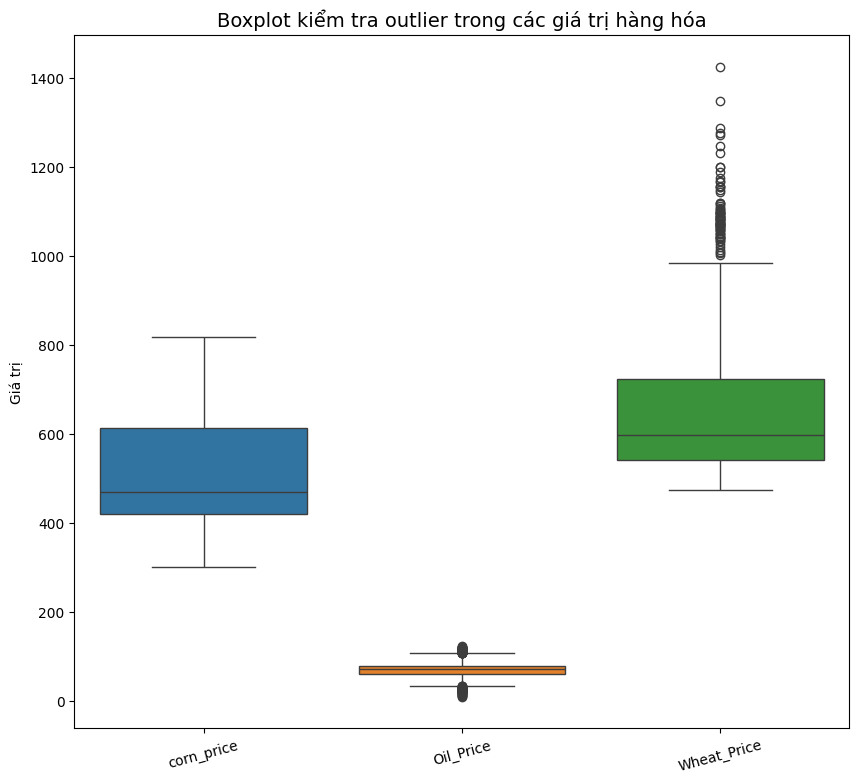

In [21]:
plt.figure(figsize=(10,9))
sns.boxplot(data=df[['corn_price', 'Oil_Price', 'Wheat_Price']])
plt.title("Boxplot kiểm tra outlier trong các giá trị hàng hóa", fontsize=14)
plt.ylabel("Giá trị")
plt.xticks(rotation=15)
plt.show()

Oil_Price:123 giá trị outliers
Tỉ lệ Outliers % Oil_Price là: 13.666666666666666 
Biến động thị trường dầu từ cuộc xung đột Nga - uKraina và Covid 19
Wheat_Price:72 giá trị outliers
Tỉ lệ Outliers % Wheat_Price là: 6.545454545454546 
=> Winsorize (clip 1%–99%)

In [22]:
def bo_outlier(data,cols):
    dt=data.copy()
    for col in cols:
        Q1 = dt[col].quantile(0.25)
        Q3 = dt[col].quantile(0.75)
        dt=dt[dt[col].between(Q1,Q3)]
    return dt

In [23]:
cols = ['Oil_Price']
df_clean = bo_outlier(df,cols)

print("Trước khi lọc:", len(df))
print("Sau khi lọc:", len(df_clean))

Trước khi lọc: 1519
Sau khi lọc: 759


In [24]:
df_clean 

,corn_price,Oil_Price,Wheat_Price,SoyBean,usd_index,price_lag_1,price_lag_7,moving_avg_7,moving_avg_30
Date,,,,,,,,,
2021-02-24,559.25,63.220001,680.25,1423.75,90.169998,553.75,538.75,551.750000,539.291667
2021-02-25,554.75,63.529999,671.75,1406.00,90.135002,559.25,552.25,552.107143,540.541667
2021-03-04,546.25,63.830002,649.75,1415.25,91.643997,550.25,553.75,553.464286,544.608333
2021-03-05,562.00,66.089996,654.00,1434.25,91.989998,546.25,559.25,553.857143,545.866667
2021-03-08,565.00,65.050003,646.50,1437.75,92.334000,562.00,554.75,555.321429,548.016667
...,...,...,...,...,...,...,...,...,...
2026-02-24,427.75,65.629997,567.50,1139.50,97.769997,427.50,431.25,427.642857,427.025000
2026-02-25,430.50,65.419998,565.75,1148.25,97.625000,427.75,431.75,427.464286,427.325000
2026-02-26,433.25,65.209999,571.75,1147.75,97.739998,430.50,426.25,428.464286,427.775000


In [39]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1428 entries, 0 to 1428
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1428 non-null   datetime64[ns]
 1   corn_price     1428 non-null   float64       
 2   Oil_Price      1428 non-null   float64       
 3   Wheat_Price    1428 non-null   float64       
 4   SoyBean        1428 non-null   float64       
 5   usd_index      1428 non-null   float64       
 6   price_lag_1    1428 non-null   float64       
 7   price_lag_7    1428 non-null   float64       
 8   moving_avg_7   1428 non-null   float64       
 9   moving_avg_30  1428 non-null   float64       
 10  Month          1428 non-null   int32         
 11  Year           1428 non-null   int32         
dtypes: datetime64[ns](1), float64(9), int32(2)
memory usage: 133.9 KB


In [26]:
df_clean[df_clean['Year']==2025]


KeyError: 'Year'

Khám phá dự liệu EDA

In [25]:
plt.Figure(figsize=(10,9))
ax= sns.barplot(x='Year',y='corn_price',data=df_clean, palette='coolwarm',estimator="mean",errorbar=("ci",95))
plt.title("Gía ngô theo từng năm(2021-2025)")
plt.xlabel('Năm(2020-2025)')
plt.ylabel('USD/unit')
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container,fmt='{:,.0f}'.format,padding=3,fontsize=10)


ValueError: Could not interpret value `Year` for `x`. An entry with this name does not appear in `data`.

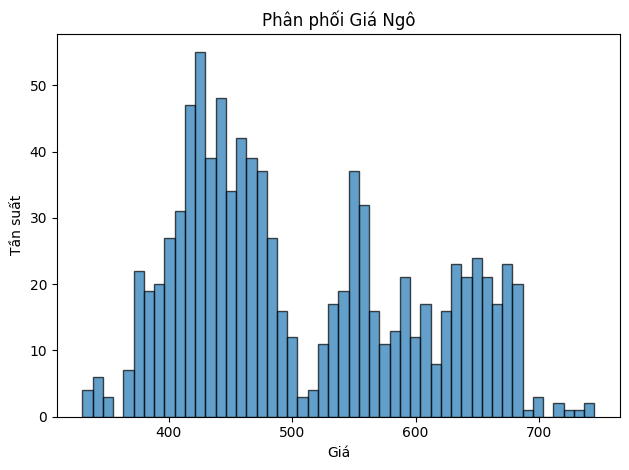

In [80]:
plt.Figure(figsize=(10,9))
plt.hist(df_clean['corn_price'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Phân phối Giá Ngô')
plt.xlabel('Giá')
plt.ylabel('Tần suất')
plt.tight_layout()

In [35]:
monthly_avg = df_clean.groupby('Month')['corn_price'].mean().reset_index()
monthly_avg

,Month,corn_price
0,1,508.705696
1,2,508.333333
2,3,492.757937
3,4,484.710526
4,5,485.008772
5,6,491.728723
6,7,554.163043
7,8,533.557018
8,9,480.372642
9,10,490.315789


Text(0, 0.5, 'Giá Trung Bình')

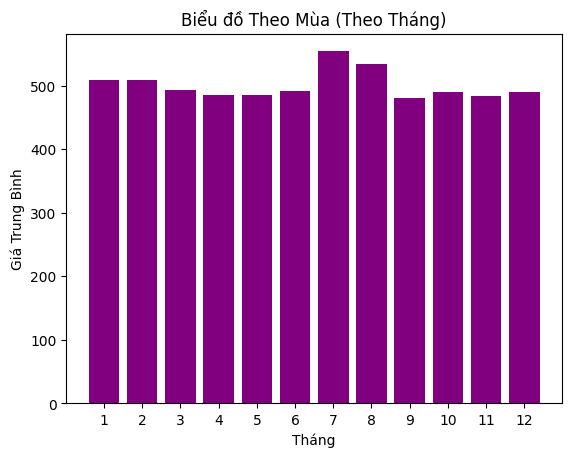

In [36]:
plt.Figure(figsize=(10,9))
plt.title('Biểu đồ Theo Mùa (Theo Tháng)')
plt.bar(monthly_avg['Month'], monthly_avg['corn_price'],color='purple')
plt.xlabel('Tháng')
plt.xticks(range(1,13))
plt.ylabel('Giá Trung Bình')

Text(0.5, 1.0, 'Tương quan với Giá Ngô')

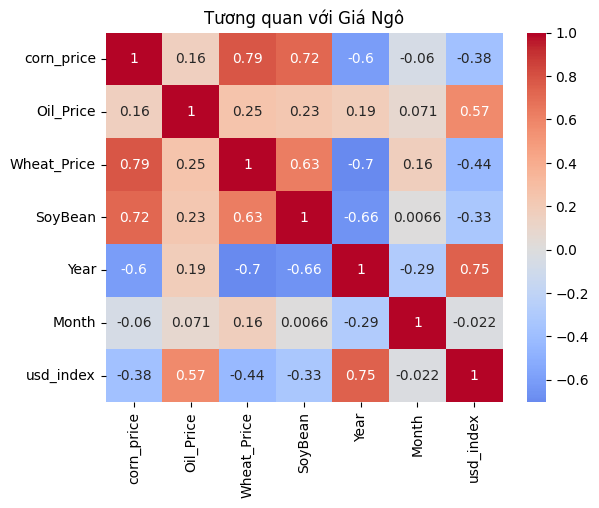

In [30]:
plt.Figure(figsize=(10,20))
cols = ['corn_price','Oil_Price','Wheat_Price','SoyBean','Year','Month','usd_index']
correlation_matrix = df_clean[cols].corr()
sns.heatmap(correlation_matrix, 
                annot=True, cmap='coolwarm', center=0)
plt.title('Tương quan với Giá Ngô')

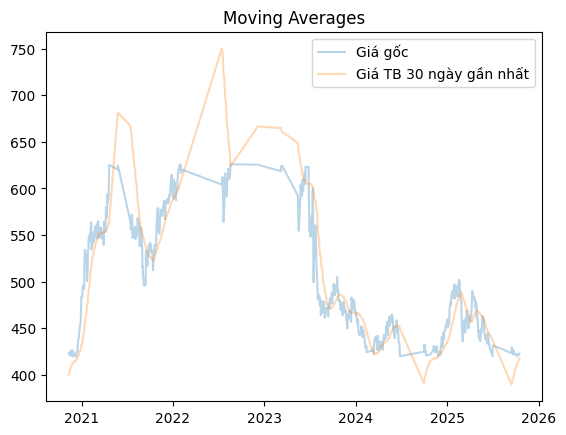

In [38]:
plt.Figure(figsize=(10,9))
plt.plot(df_clean['Date'], df_clean['corn_price'], alpha=0.3, label='Giá gốc')
plt.plot(df_clean['Date'], df_clean['moving_avg_30'], alpha=0.3, label='Giá TB 30 ngày gần nhất')
plt.title('Moving Averages')
plt.legend()

Tạo model dự đoán giá ngô - model RandomForestRegressor

Model machine learning Em có thể bỏ qua

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error #Chỉ số đánh giá model linear
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet # xgboost đã có sẵn rồi
#from sklearn.pipeline import Pipeline
#tìm hiểu early_stopping

In [65]:
df_clean.head(10)

,Date,corn_price,Oil_Price,Wheat_Price,SoyBean,usd_index,price_lag_1,price_lag_7,moving_avg_7,moving_avg_30,Month,Year
0,2020-02-13,379.50,51.419998,544.25,896.25,98.958000,383.00,382.25,381.071429,384.300000,2,2020
1,2020-02-14,377.75,52.049999,542.75,893.75,99.002998,379.50,380.75,380.642857,383.841667,2,2020
2,2020-02-18,383.00,52.049999,566.75,892.25,99.333000,377.75,379.25,381.178571,383.725000,2,2020
3,2020-02-19,380.50,53.290001,565.25,897.25,99.597000,383.00,383.50,380.750000,383.583333,2,2020
4,2020-02-20,378.50,53.779999,560.00,892.75,99.776001,380.50,381.75,380.285714,383.383333,2,2020
5,2020-02-21,377.00,53.380001,551.00,890.50,99.188004,378.50,379.75,379.892857,383.141667,2,2020
6,2020-02-24,372.25,51.430000,536.25,874.25,99.283997,377.00,383.00,378.357143,382.775000,2,2020
7,2020-02-25,372.50,49.900002,539.00,879.00,98.901001,372.25,379.50,377.357143,382.333333,2,2020
8,2020-02-26,370.50,48.730000,540.25,881.00,98.938004,372.50,377.75,376.321429,381.700000,2,2020
9,2020-02-27,364.50,47.090000,529.25,886.25,98.460999,370.50,383.00,373.678571,380.883333,2,2020


In [66]:
df_clean['Day']=df_clean['Date'].dt.day

In [67]:
df_clean

,Date,corn_price,Oil_Price,Wheat_Price,SoyBean,usd_index,price_lag_1,price_lag_7,moving_avg_7,moving_avg_30,Month,Year,Day
0,2020-02-13,379.50,51.419998,544.25,896.25,98.958000,383.00,382.25,381.071429,384.300000,2,2020,13
1,2020-02-14,377.75,52.049999,542.75,893.75,99.002998,379.50,380.75,380.642857,383.841667,2,2020,14
2,2020-02-18,383.00,52.049999,566.75,892.25,99.333000,377.75,379.25,381.178571,383.725000,2,2020,18
3,2020-02-19,380.50,53.290001,565.25,897.25,99.597000,383.00,383.50,380.750000,383.583333,2,2020,19
4,2020-02-20,378.50,53.779999,560.00,892.75,99.776001,380.50,381.75,380.285714,383.383333,2,2020,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1424,2025-10-13,410.75,59.490002,496.75,1007.75,99.029999,413.00,421.75,417.785714,414.866667,10,2025,13
1425,2025-10-14,413.00,58.700001,500.25,1006.50,98.809998,410.75,419.00,416.928571,415.200000,10,2025,14
1426,2025-10-15,416.75,58.270000,498.75,1006.50,98.541000,413.00,421.75,416.214286,415.833333,10,2025,15
1427,2025-10-16,421.75,57.459999,502.50,1010.75,98.092003,416.75,419.75,416.500000,416.566667,10,2025,16


In [68]:
df.dtypes

Date             datetime64[ns]
corn_price              float64
Oil_Price               float64
Wheat_Price             float64
SoyBean                 float64
usd_index               float64
price_lag_1             float64
price_lag_7             float64
moving_avg_7            float64
moving_avg_30           float64
Month                     int32
Year                      int32
dtype: object

In [101]:
x=df_clean.drop(columns=['corn_price','Date','SoyBean'],axis=1)
y=df_clean['corn_price']


In [102]:
x

,Oil_Price,Wheat_Price,usd_index,price_lag_1,price_lag_7,moving_avg_7,moving_avg_30,Month,Year
260,63.529999,671.75,90.135002,559.25,552.25,552.107143,540.541667,2,2021
265,63.830002,649.75,91.643997,550.25,553.75,553.464286,544.608333,3,2021
266,66.089996,654.00,91.989998,546.25,559.25,553.857143,545.866667,3,2021
267,65.050003,646.50,92.334000,562.00,554.75,555.321429,548.016667,3,2021
268,64.010002,656.50,91.963997,565.00,555.50,556.250000,549.700000,3,2021
...,...,...,...,...,...,...,...,...,...
1410,63.410000,520.50,96.892998,421.75,399.00,425.035714,397.975000,9,2025
1411,64.989998,519.50,97.517998,426.25,423.25,425.178571,399.733333,9,2025
1412,64.980003,527.00,98.214996,424.25,429.50,424.642857,401.458333,9,2025
1413,65.720001,519.75,97.823997,425.75,426.75,423.964286,403.025000,9,2025


In [71]:
from sklearn.feature_selection import VarianceThreshold

In [72]:
selector = VarianceThreshold(threshold=0)


In [103]:
scaler =StandardScaler()


In [104]:
x_scale = scaler.fit_transform(x)

In [105]:
x_var=selector.fit_transform(x_scale)

In [76]:
x_selectedf= x.columns[selector.get_support()]
x_selectedf

Index(['Oil_Price', 'Wheat_Price', 'usd_index', 'price_lag_1', 'price_lag_7',
       'moving_avg_7', 'moving_avg_30', 'Month', 'Year', 'Day'],
      dtype='object')

In [77]:
rf= XGBRegressor(random_state=42,n_jobs=-1)
params={
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, ],
    'learning_rate': [ 0.05,0.1],
    'subsample': [0.9, 1.0],
    'colsample_bytree': [0.9, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1]}
tscv = TimeSeriesSplit(n_splits=5)


In [78]:
gridscv= GridSearchCV(estimator=rf, param_grid=params,cv=tscv,
    verbose=1)

In [106]:
gridscv.fit(x_scale,y)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.9, 1.0], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [107]:
result=pd.DataFrame(gridscv.cv_results_)


In [108]:
result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_reg_alpha,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.064722,0.023054,0.002993,0.000264,0.9,0.05,3,100,0.0,1,0.9,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.621401,0.830149,-1.878312,0.835335,0.957903,0.273295,1.081227,133
1,0.044752,0.004780,0.002825,0.000197,0.9,0.05,3,100,0.0,1,1.0,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.551217,0.820564,-1.806645,0.841912,0.960767,0.273563,1.048698,132
2,0.044764,0.007161,0.003089,0.000510,0.9,0.05,3,100,0.1,1,0.9,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.618568,0.823948,-1.942383,0.839622,0.957907,0.259532,1.106357,135
3,0.061390,0.010721,0.002888,0.000159,0.9,0.05,3,100,0.1,1,1.0,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.582972,0.817750,-1.761046,0.848504,0.960136,0.289663,1.032681,130
4,0.045850,0.003210,0.002810,0.000253,0.9,0.05,3,100,1.0,1,0.9,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.623006,0.815832,-1.992390,0.842764,0.960371,0.249917,1.126375,141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.236590,0.045475,0.003370,0.000360,1.0,0.10,5,300,0.0,1,1.0,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.485074,0.793961,-1.086499,0.858415,0.952390,0.400668,0.759921,20
140,0.239949,0.037909,0.003280,0.000538,1.0,0.10,5,300,0.1,1,0.9,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.521199,0.801135,-1.138021,0.858126,0.951344,0.398757,0.781660,27
141,0.232101,0.040395,0.003539,0.000227,1.0,0.10,5,300,0.1,1,1.0,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.487296,0.811104,-1.015326,0.871432,0.955172,0.421935,0.735912,7
142,0.258769,0.056726,0.003506,0.000354,1.0,0.10,5,300,1.0,1,0.9,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.458704,0.795118,-1.253592,0.868513,0.955719,0.364893,0.826571,83


In [78]:
result[['params','mean_test_score','rank_test_score']]

,params,mean_test_score,rank_test_score
0,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.838973,54
1,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.830615,79
2,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.838873,56
3,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.828690,84
4,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.848187,23
...,...,...,...
139,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.796092,138
140,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.829988,83
141,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.793635,140
142,"{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.836340,62


In [79]:
result[result['rank_test_score']==1]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_colsample_bytree,param_learning_rate,param_max_depth,param_n_estimators,param_reg_alpha,param_reg_lambda,param_subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
10,0.100433,0.005063,0.003536,0.000967,0.9,0.05,3,200,1.0,1,0.9,"{'colsample_bytree': 0.9, 'learning_rate': 0.0...",0.71006,0.929748,0.847847,0.882918,0.926451,0.859405,0.08054,1


In [80]:
xgb_model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=1,
        reg_lambda=1,
        random_state=42
    )
    
tscv = TimeSeriesSplit(n_splits=5)

In [81]:
xgb_model.fit(x_scale, y)

y_pred = xgb_model.predict(x_scale)

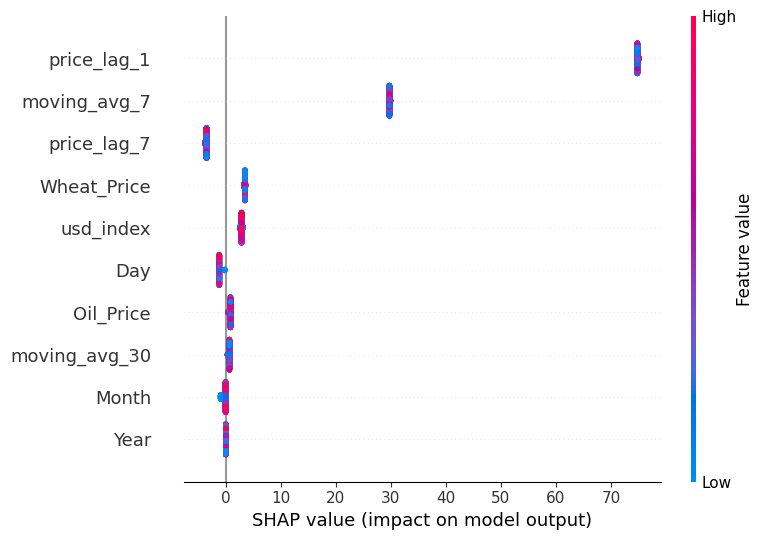

In [82]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(x)
shap.summary_plot(shap_values, x)

In [60]:
from sklearn.model_selection import cross_val_score

In [59]:
cv_scores = cross_val_score(xgb_model, x_scale, y, cv=tscv,scoring='r2')
cv_mae = cross_val_score(xgb_model, x_scale, y, cv=tscv, scoring='neg_mean_absolute_error')
    

In [60]:
cv_scores

array([0.7100602 , 0.92974848, 0.84784665, 0.88291842, 0.92645914])

In [61]:
cv_mae

array([-14.41957105, -11.78420482,  -6.63576629,  -4.98706157,
        -4.83508352])